<a href="https://colab.research.google.com/github/lukwac123/computer_vision_course/blob/main/02_document-scaner/02_document_scaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab.patches import cv2_imshow
from skimage.filters import threshold_local
import numpy as np
from numpy.linalg import norm
import imutils
import cv2

In [5]:
image = cv2.imread('paragon_1.jpg')
image.shape

(600, 450, 3)

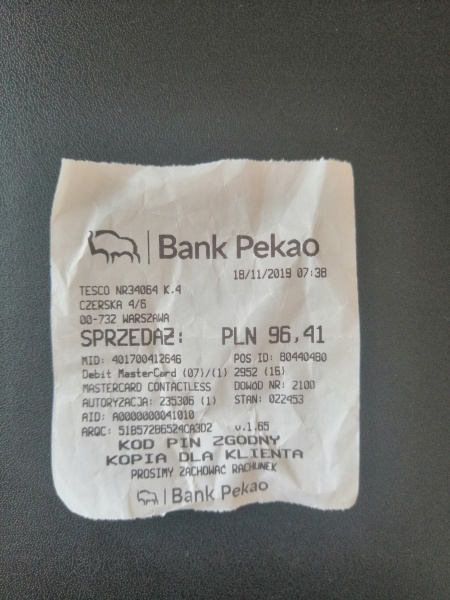

In [6]:
cv2_imshow(image)

Standaryzacja rozmiaru

In [7]:
# zachowamy kopię oryginalnego obrazu do późniejszych przekształceń
original_image = image.copy()

# zachowamy proporcję oryginalnego obrazu
ratio = image.shape[0] / 500.0

# zmiana rozmiary do wysokości 500 pikseli
image = imutils.resize(image, height=500)
image.shape

(500, 375, 3)

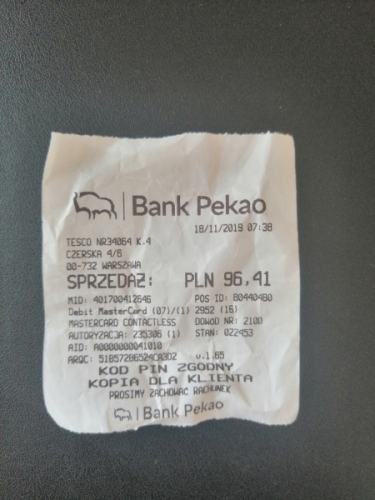

In [8]:
cv2_imshow(image)

Konwersja obrazu do skali szarości

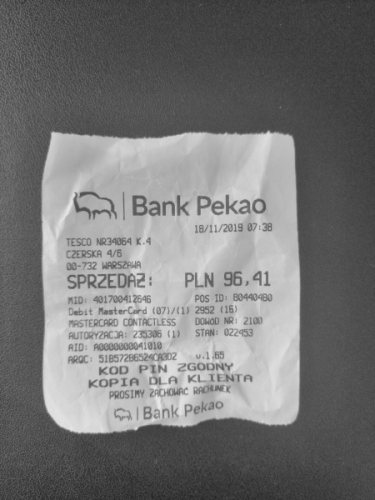

In [9]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray_image)

Detekcja krawędzi

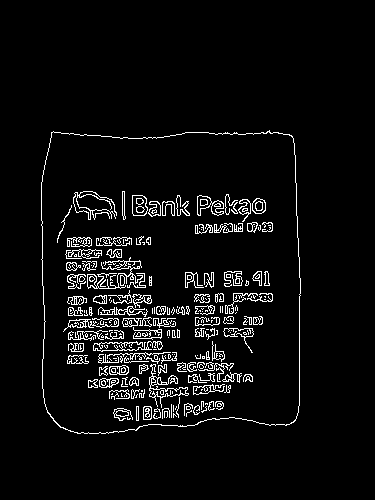

In [10]:
edges = cv2.Canny(gray_image, threshold1=75, threshold2=200)
cv2_imshow(edges)

Rozmycie

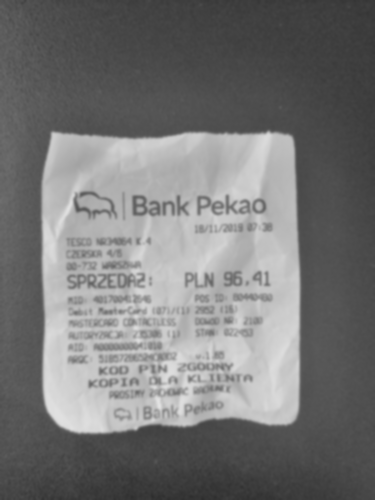

In [11]:
gray_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
cv2_imshow(gray_image)

Detekcja krawędzi po rozmyciu

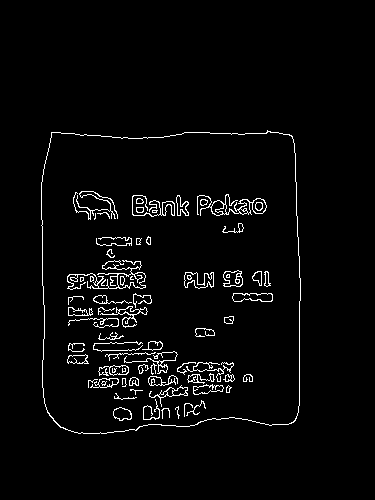

In [12]:
edges = cv2.Canny(gray_image, threshold1=75, threshold2=200)
cv2_imshow(edges)

Znalezienie konturu dokumentu

In [13]:
contours = cv2.findContours(image=edges.copy(), mode=cv2.RETR_LIST, method=cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)
print(f'Liczba wszystkich wyszukanych punktów (kontur): {len(contours)}')
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

for contour in contours:
  print(len(contour))


Liczba wszystkich wyszukanych punktów (kontur): 135
217
215
189
356
83


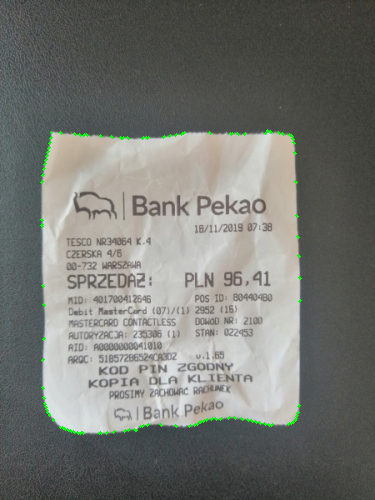

In [14]:
cnt1 = cv2.drawContours(image.copy(), contours[0], -1, (0, 255, 0), 2)
cv2_imshow(cnt1)

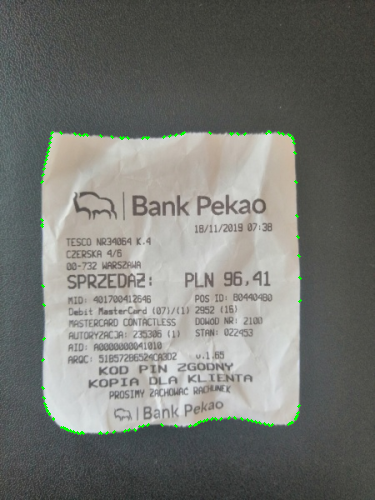

In [15]:
cnt2 = cv2.drawContours(image.copy(), contours[1], -1, (0, 255, 0), 2)
cv2_imshow(cnt2)

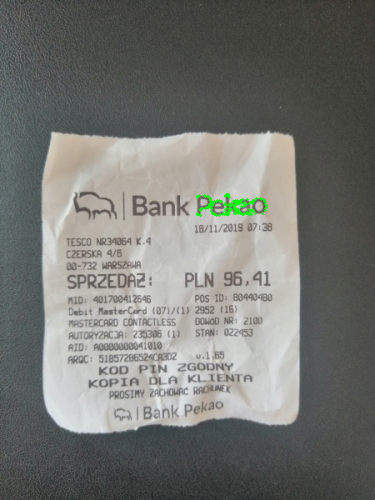

In [16]:
cnt3 = cv2.drawContours(image.copy(), contours[2], -1, (0, 255, 0), 2)
cv2_imshow(cnt3)

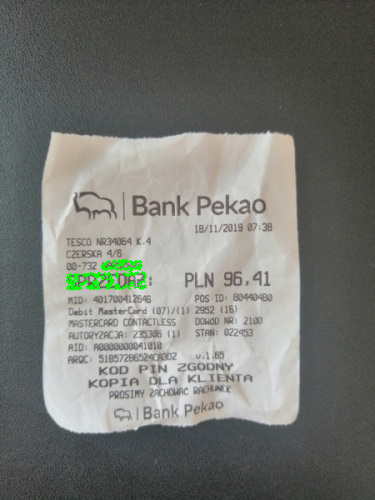

In [17]:
cnt4 = cv2.drawContours(image.copy(), contours[3], -1, (0, 255, 0), 2)
cv2_imshow(cnt4)

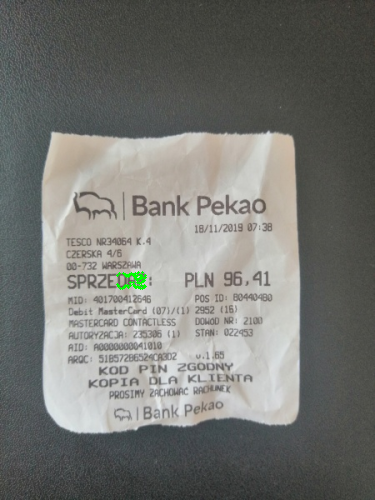

In [18]:
cnt5 = cv2.drawContours(image.copy(), contours[4], -1, (0, 255, 0), 2)
cv2_imshow(cnt5)

In [19]:
for contour in contours:
  print('Sprawdzenie...')
  # obliczamy obwód każdej wyszukanej figury
  perimeter = cv2.arcLength(curve=contour, closed=True)

  # przybliżenie krzywej wielokąta (w naszym przypadku prostokąt) z określoną precyzją
  approx = cv2.approxPolyDP(curve=contour, epsilon=0.02 * perimeter, closed=True)

  if len(approx) == 4:
    screen_contour = approx
    break

print(screen_contour)

Sprawdzenie...
[[[291 135]]

 [[ 51 132]]

 [[ 60 427]]

 [[295 420]]]


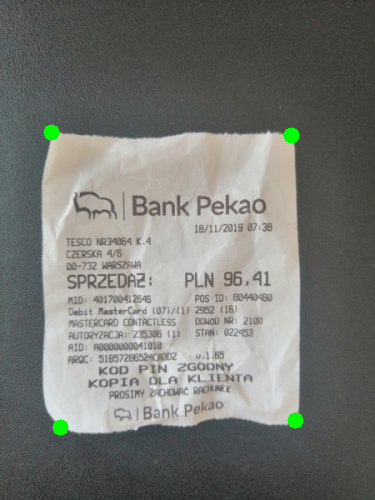

In [20]:
# wyświetlanie znalezionych wierzchołków
cv2.drawContours(image, contours=screen_contour, contourIdx=-1, color=(0, 255, 0), thickness=15)
cv2_imshow(image)

Ekstrakcja wierzchołków

In [21]:
points = screen_contour.reshape(4, 2)
points = points * ratio
points

array([[349.2, 162. ],
       [ 61.2, 158.4],
       [ 72. , 512.4],
       [354. , 504. ]])

In [22]:
rectangle = np.zeros((4, 2), dtype='float32')
rectangle

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)

In [23]:
total = points.sum(axis=1)

rectangle[0] = points[np.argmin(total)]
rectangle[2] = points[np.argmax(total)]
rectangle

array([[ 61.2, 158.4],
       [  0. ,   0. ],
       [354. , 504. ],
       [  0. ,   0. ]], dtype=float32)

In [25]:
difference = np.diff(points, axis=1)
rectangle[1] = points[np.argmin(difference)]
rectangle[3] = points[np.argmax(difference)]
rectangle

array([[ 61.2, 158.4],
       [349.2, 162. ],
       [354. , 504. ],
       [ 72. , 512.4]], dtype=float32)

In [26]:
(a, b, c, d) = rectangle
width1 = norm(c - d)
width2 = norm(b - a)
max_width = max(int(width1), int(width2))

height1 = norm(b - c)
height2 = norm(a - d)
max_height = max(int(height1), int(height2))

print(f'max_width: {max_width}')
print(f'max_height: {max_height}')

max_width: 288
max_height: 354


In [28]:
vertices = np.array([
    [0, 0],
    [max_width - 1, 0],
    [max_width - 1, max_height - 1],
    [0, max_height - 1]
], dtype='float32')

vertices

array([[  0.,   0.],
       [287.,   0.],
       [287., 353.],
       [  0., 353.]], dtype=float32)

Transformacja wyszukiwanego dokumentu do oberazu: getPerspectiveTransform() - zwraca macierz transformacji

In [29]:
# macierz transformacji 3x3
M = cv2.getPerspectiveTransform(rectangle, vertices)
M

array([[ 9.47714238e-01, -2.89133112e-02, -5.34202438e+01],
       [-1.20274799e-02,  9.62196799e-01, -1.51675885e+02],
       [-1.16837073e-04, -5.27577240e-05,  1.00000000e+00]])

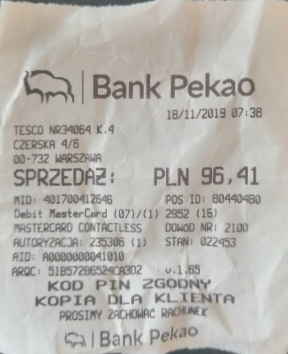

In [30]:
# przekształcenie dokumentu do obrazu
out = cv2.warpPerspective(src=original_image, M=M, dsize=(max_width, max_height))
cv2_imshow(out)

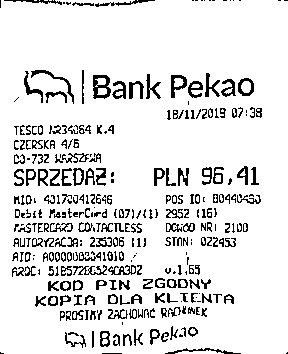

In [31]:
# konwersja do skali szarości
out =  cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)

# obliczenie maski progowej na podstawie sąsiedztwa pikseli
T = threshold_local(image=out, block_size=11, offset=10, method='gaussian')
out = (out > T).astype('uint8') * 255
cv2_imshow(out)